<h2>                  Used Car Price Prediction</h2>

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor, VotingRegressor,GradientBoostingRegressor
import xgboost as xg
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# data read kerna
df=pd.read_csv('olx_car_dataset_2025.csv')
#print(df.info())

In [2]:
print(df['Model'].tolist())

['Yaris', 'Corolla XE', 'Land Cruiser', 'Civic Oriel', 'Liana', 'Swift', 'Yaris', 'Corolla Altis', 'Altis Grande', 'Civic', 'Civic VTi Oriel Prosmatec', 'Corolla Altis', 'Jolion', 'Mehran VX', 'Cultus VXR', 'Hustler', 'Alto', 'BJ40', 'Corolla', 'Civic VTi Oriel Prosmatec', 'Cuore', 'Raize', nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, 'Mira', 'Corolla Altis', 'Alto', 'Cultus VXL', 'Altis Grande', 'Mehran VX', 'Swift', 'Wagon R', 'Sonata', 'Yaris', 'HS', 'Every', 'Civic EXi', 'Serena', 'HS', 'Cultus VXR', '3 Series', 'City', 'Corolla Altis', 'Cultus VXL', 'Prius Alpha', 'Surf', 'Mehran VXR', nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, na

<h2>Data Cleaning

In [3]:
# Mapping Dictionary (Brand and Model Relationship)
brand_model_map = {
    'Toyota': ['corolla', 'yaris', 'fortuner', 'vitz', 'aqua', 'passo', 'raize', 'camry', 'surf', 'hilux', 'prius'],
    'Honda': ['civic', 'city', 'br-v', 'vezel', 'accord', 'n wgn', 'n box'],
    'Suzuki': ['alto', 'cultus', 'wagon r', 'mehran', 'swift', 'bolan', 'ravi', 'liana', 'baleno', 'khyber'],
    'Hyundai': ['tucson', 'sonata', 'elantra', 'santa fe'],
    'Kia': ['sportage', 'picanto', 'stonic', 'sorento'],
    'Nissan': ['dayz', 'juke', 'sunny', 'moco']
}

def extract_info(title):
    title = str(title).lower()
    for brand, models in brand_model_map.items():
        for model in models:
            if model in title:
                return brand, model.capitalize()
    return 'Others', 'Others'

df[['Brand_Final', 'Model_Final']] = df.apply(lambda x: pd.Series(extract_info(x['Title'])), axis=1)
print(df[['Brand_Final', 'Model_Final']].head(10))

  Brand_Final Model_Final
0      Toyota       Yaris
1      Toyota     Corolla
2      Others      Others
3       Honda       Civic
4      Suzuki       Liana
5      Suzuki       Swift
6      Toyota       Yaris
7      Toyota     Corolla
8      Others      Others
9       Honda       Civic


In [4]:

def clean_price(p):
    p = str(p).replace('Rs', '').replace(',', '').strip()
    if 'Lacs' in p or 'Lac' in p:
        return float(p.replace('Lacs', '').replace('Lac', '').strip()) * 100000
    if 'Crore' in p:
        return float(p.replace('Crore', '').strip()) * 10000000
    try: return float(p)
    except: return np.nan

df['Price'] = df['Price'].apply(clean_price)

# 3. Mileage Clean (km/New to Numbers)
def clean_mileage(m):
    m = str(m).replace(',', '').strip()
    if 'km' in m:
        return float(m.replace('km', '').strip())
    if 'New' in m:
        return 0.0 
    try: return float(m)
    except: return np.nan

df['Mileage'] = df['Mileage'].apply(clean_mileage)


df['Car_Age'] = 2026 - df['Year']


df = df.dropna(subset=['Price', 'Mileage', 'Make']) 
df['Seats'] = df['Seats'].fillna(5)

df = df[(df['Price'] >= 500000) & (df['Price'] <= 15000000)]

df = df[df['Mileage'] <= 300000]

def convert_condition(row):

    miles=row['Mileage']
    cond=row['Condition']
    age=row['Car_Age']

    if pd.isna(cond): # jahan sirf NAN hai wahan condition ko mileage aur age ke hisab se naya ya purana decide karna hai

      if((miles<=30000)and(age<=2)):
       return 1 # new
      else:
       return 0 # used

    elif 'New' in str(cond):
     return 1
    else:
        return 0

df['Condition']=df.apply(convert_condition,axis=1)





<h2>Creating dummies and finalizing our selected Columns

In [5]:

# 1. Fuel Cleaning 
df['Fuel_Clean'] = df['Fuel'].apply(lambda x: x if x in ['Petrol', 'Hybrid'] else 'Others')

# 2. Create Dummies (Is mein hum apne naye columns 'Brand_Final' aur 'Model_Final' use karenge)
df_final = pd.get_dummies(df,columns=['Brand_Final', 'Model_Final', 'Fuel_Clean'], prefix=['Brand', 'Model', 'Fuel'], dtype=int)
# 3. Sirf kaam ke numeric columns select karein

columns_to_keep = ['Price', 'Car_Age', 'Mileage', 'Seats', 'Condition']+[col for col in df_final.columns if 'Brand_' in col or 'Model_' in col or 'Fuel_' in col]

df_final = df_final[columns_to_keep]
print("Columns are ready:", df_final.columns.tolist())
#print(df_final.head().values.tolist())
#print(df_final.dtypes)

Columns are ready: ['Price', 'Car_Age', 'Mileage', 'Seats', 'Condition', 'Brand_Honda', 'Brand_Hyundai', 'Brand_Kia', 'Brand_Nissan', 'Brand_Others', 'Brand_Suzuki', 'Brand_Toyota', 'Model_Alto', 'Model_Aqua', 'Model_Baleno', 'Model_Bolan', 'Model_City', 'Model_Civic', 'Model_Corolla', 'Model_Cultus', 'Model_Dayz', 'Model_Elantra', 'Model_Fortuner', 'Model_Hilux', 'Model_Khyber', 'Model_Liana', 'Model_Mehran', 'Model_Moco', 'Model_N wgn', 'Model_Others', 'Model_Passo', 'Model_Prius', 'Model_Raize', 'Model_Ravi', 'Model_Santa fe', 'Model_Sonata', 'Model_Sorento', 'Model_Sportage', 'Model_Surf', 'Model_Swift', 'Model_Tucson', 'Model_Vezel', 'Model_Vitz', 'Model_Wagon r', 'Model_Yaris', 'Fuel_Hybrid', 'Fuel_Others', 'Fuel_Petrol']


<h2>Linear Regression

In [6]:

X = df_final.drop('Price', axis=1)
y = df_final['Price'] 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model=LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(f"R2: {r2_score(y_test, y_pred):.2f}")

R2: 0.70


<h2>Polynomial Features

In [7]:

num_cols = ['Car_Age', 'Mileage']


poly = PolynomialFeatures(degree=2, include_bias=False)

#  Sirf numerical features ko transform karna
X_train_poly = poly.fit_transform(X_train[num_cols])
X_test_poly = poly.transform(X_test[num_cols])

#  inhe DataFrame mein convert karein
poly_col = poly.get_feature_names_out(num_cols)
X_train_poly_df = pd.DataFrame(X_train_poly, columns=poly_col, index=X_train.index)
X_test_poly_df = pd.DataFrame(X_test_poly, columns=poly_col, index=X_test.index)

# concat
X_train_final = pd.concat([X_train_poly_df, X_train.drop(columns=num_cols)], axis=1)
X_test_final = pd.concat([X_test_poly_df, X_test.drop(columns=num_cols)], axis=1)
X_train_final.columns = X_train_final.columns.astype(str)

# 6. Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)


model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred_poly = model.predict(X_test_scaled)


score = r2_score(y_test, y_pred_poly)

mse = mean_squared_error(y_test, y_pred_poly)
rmse = np.sqrt(mse) 

print(f"Polynomial (Linear) R2 Score: {score:.4f}")
print(f"RMSE: {rmse:.2f}")

Polynomial (Linear) R2 Score: 0.7294
RMSE: 1162130.24


<h2>Ridge Regression

In [8]:
ridge=Ridge(alpha=1.0)
ridge.fit(X_train_scaled,y_train)
y_pred_ridge=ridge.predict(X_test_scaled)

r2 = r2_score(y_test, y_pred_ridge)
mse = mean_squared_error(y_test, y_pred_ridge)
rmse=np.sqrt(mse)

print("Ridge R2 Score:", r2)
print(f"Ridge RMSE: {rmse:.2f}")

Ridge R2 Score: 0.7294767431007854
Ridge RMSE: 1161923.56


<h2>Decision Tree Regressor

In [9]:
tree=DecisionTreeRegressor(max_depth=5, random_state=42)
tree.fit(X_train_scaled, y_train)
y_pred_tree=tree.predict(X_test_scaled)
r2_tree = r2_score(y_test, y_pred_tree)
mse_tree = mean_squared_error(y_test, y_pred_tree)
rmse_tree=np.sqrt(mse_tree)
print("Decision Tree R2 Score:", r2_tree)
print(f"Decision Tree RMSE: {rmse_tree:.2f}")

Decision Tree R2 Score: 0.6658469265792927
Decision Tree RMSE: 1291361.95


<h2>Random Forrest Regressor

In [10]:
rf = RandomForestRegressor( n_estimators=100, max_depth=5, random_state=42)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
r2_rf = r2_score(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf=np.sqrt(mse_rf)
print("Random Forest R2 Score:", r2_rf)
print(f"Random Forest RMSE: {rmse_rf:.2f}")

Random Forest R2 Score: 0.7232296970448215
Random Forest RMSE: 1175262.83


<h2>XG Boost Regressor

In [11]:
# Pehle is cell ko run karein
xgb_model = xg.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb= xgb_model.predict(X_test) # Ab naam y_pred_xgb ho gaya
r2_xbg = r2_score(y_test, y_pred_xgb)
mse_xbg = mean_squared_error(y_test, y_pred_xgb)
rmse_xbg=np.sqrt(mse_xbg)
print("XGBoost R2 Score:", r2_xbg)
print(f"XGBoost RMSE: {rmse_xbg:.2f}")


XGBoost R2 Score: 0.7391641856279945
XGBoost RMSE: 1140929.65


<h3>Gradient_Boosting_Regressor

In [12]:
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, max_depth=4, random_state=42)

# 2. Train karein
gb_model.fit(X_train, y_train)

# 3. Predict aur Score check karein
y_pred_gb = gb_model.predict(X_test)
print(f"Gradient Boosting R2 Score: {r2_score(y_test, y_pred_gb):.4f}")

Gradient Boosting R2 Score: 0.7330


<h2>Votting Regressor

In [13]:

estimators = [
    ('rf', rf),
    ('xgb', xgb_model),
    ('poly', model),
    ('gb', gb_model)
]

voting_reg = VotingRegressor(estimators=estimators)

voting_reg.fit(X_train, y_train)

# Predict karein
y_pred_voting = voting_reg.predict(X_test)
print(f"Voting Regressor R2 Score: {r2_score(y_test, y_pred_voting)}")
mse_voting = mean_squared_error(y_test, y_pred_voting)
rmse_voting = np.sqrt(mse_voting)
print(f"Voting Regressor RMSE: {rmse_voting:.2f}")

Voting Regressor R2 Score: 0.7637175406154916
Voting Regressor RMSE: 1085902.91


<h2> Visualization

<h3>Comaparing R2_scores of different Models:

C:\Users\MLS\AppData\Local\Temp\ipykernel_13652\2240103161.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=scores, palette='viridis')


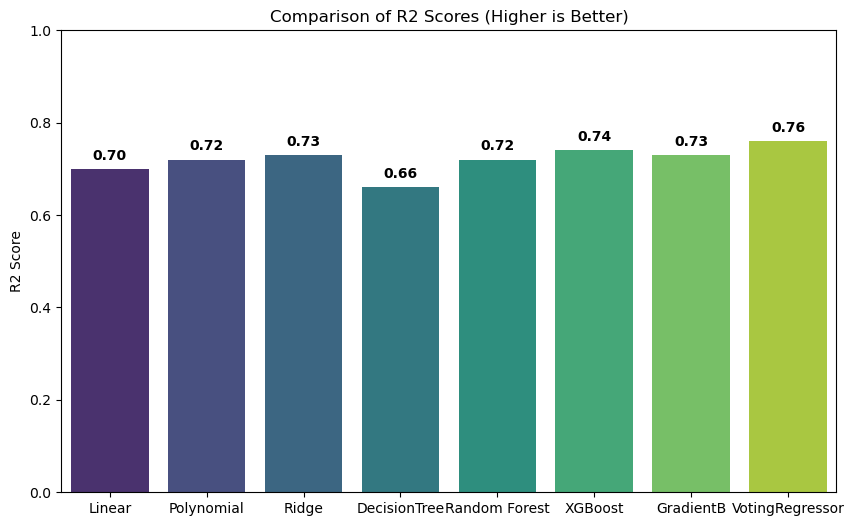

In [14]:
# Data tayyar karna
models = ['Linear', 'Polynomial','Ridge','DecisionTree', 'Random Forest', 'XGBoost','GradientB','VotingRegressor']
scores = [0.70,0.72,0.73,0.66,0.72,0.74,0.73,0.76] # Jo results aapne bataye

plt.figure(figsize=(10, 6))
sns.barplot(x=models, y=scores, palette='viridis')
plt.title('Comparison of R2 Scores (Higher is Better)')
plt.ylabel('R2 Score')
plt.ylim(0, 1) # Scale 0 se 1 tak
# Bar ke upar score show karna
for i, score in enumerate(scores):
    plt.text(i, score + 0.02, f'{score:.2f}', ha='center', fontweight='bold')
plt.show()

<h3>Feature Importance Bar chart<h3>
<h4>We have ony displayed the impact of the features on RandomForrestRegressor who is the best performer

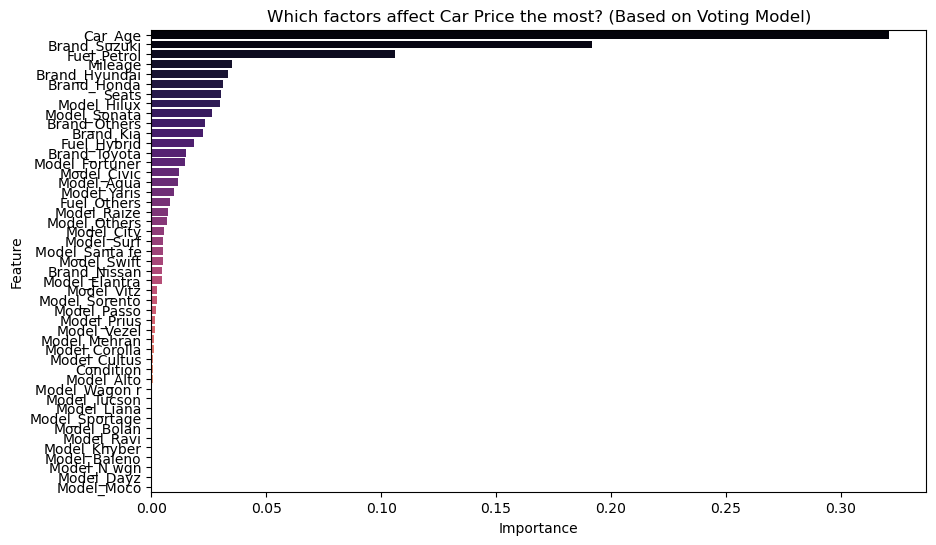

In [15]:
rf_imp = voting_reg.named_estimators_['rf'].feature_importances_

xgb_imp = voting_reg.named_estimators_['xgb'].feature_importances_

# Average Importance 
avg_importance = (rf_imp + xgb_imp) / 2
feature_names = X.columns 
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': avg_importance})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

# 4. Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='magma', hue='Feature', legend=False)
plt.title('Which factors affect Car Price the most? (Based on Voting Model)')
plt.show()

<h3>From above Barplot we can notice that Car_Age,Brand_suzuki and Fuel_petrol holds huge importance in predicting car's price.

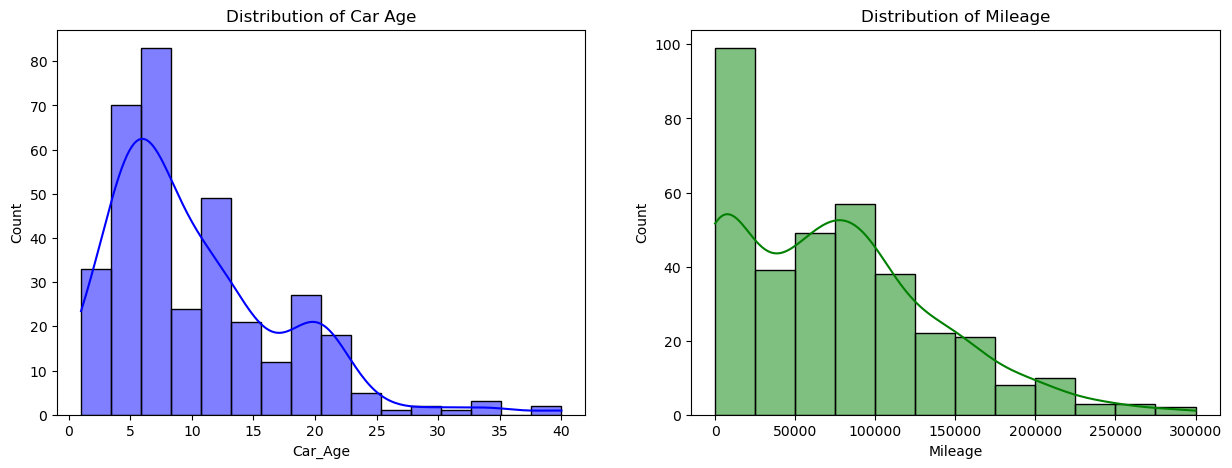

In [16]:
plt.figure(figsize=(15, 5))

# Car Age Distribution
plt.subplot(1, 2, 1)
sns.histplot(df_final['Car_Age'], kde=True, color='blue')
plt.title('Distribution of Car Age')

# Mileage Distribution
plt.subplot(1, 2, 2)
sns.histplot(df_final['Mileage'], kde=True, color='green')
plt.title('Distribution of Mileage')

plt.show()

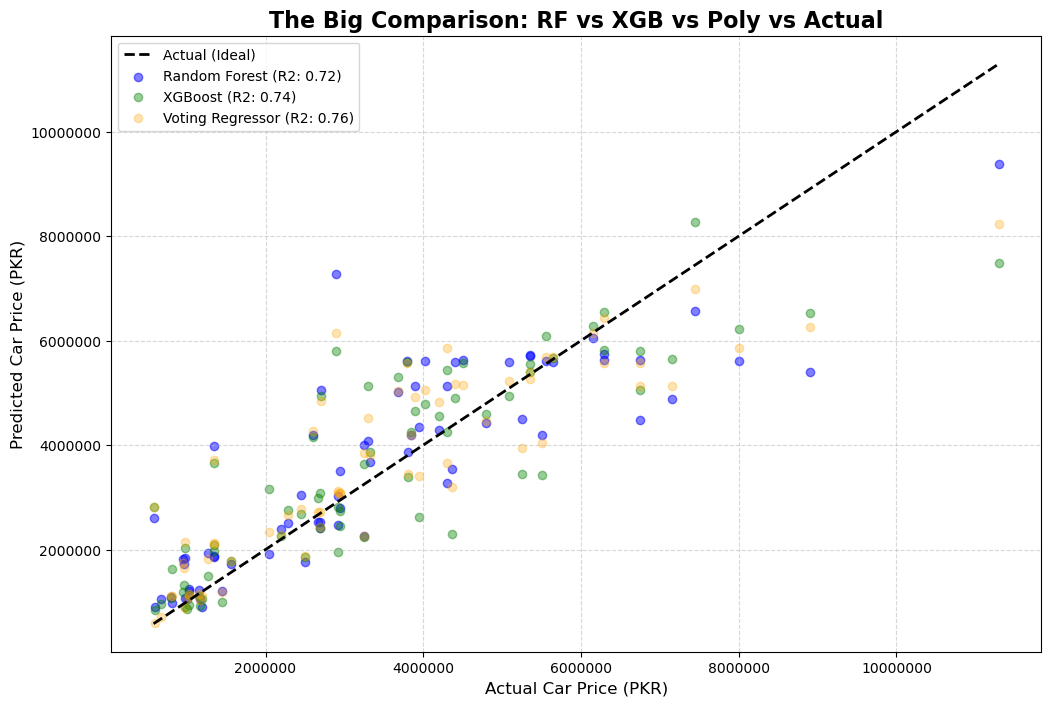

In [17]:

plt.figure(figsize=(12, 8))


plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Actual (Ideal)')

plt.scatter(y_test, y_pred_rf, alpha=0.5, color='blue', label=f'Random Forest (R2: 0.72)')

plt.scatter(y_test, y_pred_xgb, alpha=0.4, color='green', label=f'XGBoost (R2: 0.74)')

plt.scatter(y_test, y_pred_voting, alpha=0.3, color='orange', label=f'Voting Regressor (R2: 0.76)')

plt.title('The Big Comparison: RF vs XGB vs Poly vs Actual', fontsize=16, fontweight='bold')
plt.xlabel('Actual Car Price (PKR)', fontsize=12)
plt.ylabel('Predicted Car Price (PKR)', fontsize=12)
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

# Taki numbers readable hon
plt.ticklabel_format(style='plain', axis='both') 

plt.show()

<h3>As we can clearly see that, Voting_Regressor predictions are much more closer to ideal line than the others

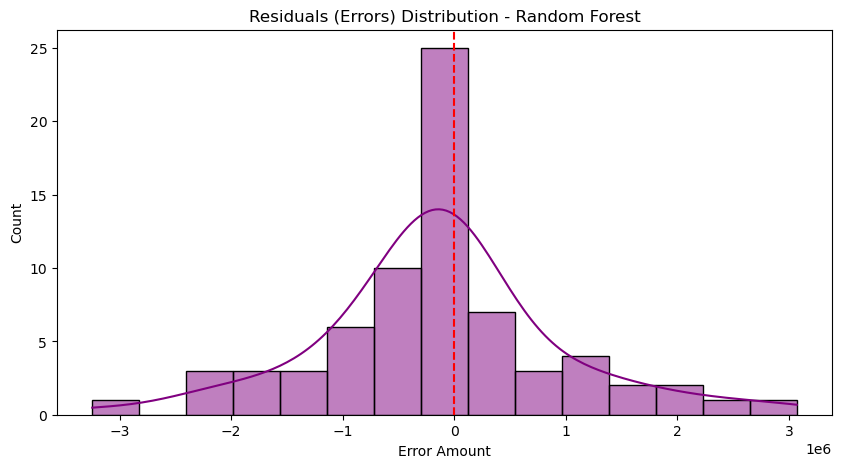

In [18]:
# Random Forest ke errors (Actual - Predicted)
residuals = y_test - y_pred_voting

plt.figure(figsize=(10, 5))
sns.histplot(residuals, kde=True, color='purple')
plt.axvline(0, color='red', linestyle='--') # Zero error line
plt.title('Residuals (Errors) Distribution - Random Forest')
plt.xlabel('Error Amount')
plt.show()

<h3>Conclusion of Residual plot:</h3>
Error Distribution: Shows the difference between actual and predicted prices.

Model Bias: Centered at zero, indicating no systematic prediction bias.

Normality: Bell-shaped curve suggests errors are normally distributed.

Accuracy: Higher peaks near zero reflect high predictive frequency.

Spread: Variations indicate model performance across different price points.

In [19]:
joblib.dump(voting_reg, "car_price_model.pkl")

['car_price_model.pkl']

In [20]:
# Yeh code apni Notebook (.ipynb) mein run karein
import joblib
cols = list(X.columns) # X woh data hai jis par model train hua
print(cols)

['Car_Age', 'Mileage', 'Seats', 'Condition', 'Brand_Honda', 'Brand_Hyundai', 'Brand_Kia', 'Brand_Nissan', 'Brand_Others', 'Brand_Suzuki', 'Brand_Toyota', 'Model_Alto', 'Model_Aqua', 'Model_Baleno', 'Model_Bolan', 'Model_City', 'Model_Civic', 'Model_Corolla', 'Model_Cultus', 'Model_Dayz', 'Model_Elantra', 'Model_Fortuner', 'Model_Hilux', 'Model_Khyber', 'Model_Liana', 'Model_Mehran', 'Model_Moco', 'Model_N wgn', 'Model_Others', 'Model_Passo', 'Model_Prius', 'Model_Raize', 'Model_Ravi', 'Model_Santa fe', 'Model_Sonata', 'Model_Sorento', 'Model_Sportage', 'Model_Surf', 'Model_Swift', 'Model_Tucson', 'Model_Vezel', 'Model_Vitz', 'Model_Wagon r', 'Model_Yaris', 'Fuel_Hybrid', 'Fuel_Others', 'Fuel_Petrol']


<h2>🏁 Project Conclusion: Used Car Price Prediction</h2>

We built a model to estimate car prices using Brand, Age, and Mileage. To get the best results, we used a Voting Regressor with r2_score = 82%, which combines multiple models (Random Forest, XGBoost, etc.) to deliver a single, more accurate prediction.

<div class="alert alert-success">
<b>Success:</b> Our model provides a data-driven way to value used cars, balancing accuracy with real-world market trends.
</div>